# **SpaceX Falcon 9 First Stage Landing Prediction**

## Advanced Machine Learning Models with SHAP Interpretability

---

### Executive Summary

This notebook implements state-of-the-art machine learning techniques to predict Falcon 9 first stage landing outcomes:

**Models Implemented:**
- XGBoost Classifier
- LightGBM Classifier
- CatBoost Classifier
- Voting Ensemble
- Stacking Classifier

**Advanced Techniques:**
- Stratified K-Fold Cross-Validation
- SMOTE for Class Imbalance
- Optuna Hyperparameter Optimization
- SHAP Model Interpretability
- Comprehensive Evaluation Metrics

---

### Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)

## Table of Contents

1. [Import Libraries & Setup](#1-import-libraries--setup)
2. [Load Enhanced Dataset](#2-load-enhanced-dataset)
3. [Data Preparation](#3-data-preparation)
4. [Class Imbalance Handling with SMOTE](#4-class-imbalance-handling-with-smote)
5. [XGBoost Model](#5-xgboost-model)
6. [LightGBM Model](#6-lightgbm-model)
7. [CatBoost Model](#7-catboost-model)
8. [Ensemble Methods](#8-ensemble-methods)
9. [Model Comparison](#9-model-comparison)
10. [SHAP Interpretability](#10-shap-interpretability)
11. [Final Model Export](#11-final-model-export)

---

## 1. Import Libraries & Setup

In [1]:
# Install required packages if not available
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install ML libraries
packages = ['xgboost', 'lightgbm', 'catboost', 'shap', 'optuna', 'imbalanced-learn']
for pkg in packages:
    try:
        __import__(pkg.replace('-', '_'))
    except ImportError:
        print(f"Installing {pkg}...")
        install_package(pkg)

print("All packages installed successfully!")

Installing imbalanced-learn...
All packages installed successfully!


In [2]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, 
    GridSearchCV, RandomizedSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, matthews_corrcoef,
    jaccard_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, VotingClassifier, 
    StackingClassifier, GradientBoostingClassifier
)

# Advanced ML
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP for interpretability
import shap

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler

# Model persistence
import joblib
import pickle

# Display settings
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"SHAP version: {shap.__version__}")

Libraries imported successfully!
XGBoost version: 3.1.2
LightGBM version: 4.6.0
SHAP version: 0.50.0


---

## 2. Load Enhanced Dataset

In [3]:
# Try to load the enhanced dataset, fall back to original if not available
try:
    df = pd.read_csv('Datasets/dataset_enhanced_features.csv')
    print("Loaded enhanced feature dataset")
except FileNotFoundError:
    print("Enhanced dataset not found. Running feature engineering...")
    # If enhanced dataset doesn't exist, load original and create basic features
    df = pd.read_csv('Datasets/dataset_part_2.csv')
    
    # Convert Date to datetime and extract basic features
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['DaysSinceFirstLaunch'] = (df['Date'] - df['Date'].min()).dt.days
    
    # Sort and create cumulative features
    df = df.sort_values('Date').reset_index(drop=True)
    df['CumulativeFlightNumber'] = range(1, len(df) + 1)
    df['OverallRollingSuccess_5'] = df['Class'].shift(1).rolling(window=5, min_periods=1).mean().fillna(0.5)
    
    # Convert boolean columns
    for col in ['GridFins', 'Reused', 'Legs']:
        df[col] = df[col].astype(int)
    
    # One-hot encode categorical columns
    categorical_cols = ['Orbit', 'LaunchSite']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
    
    # Drop non-feature columns
    drop_cols = ['Date', 'BoosterVersion', 'Outcome', 'LandingPad', 'Serial']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())

Loaded enhanced feature dataset
Dataset shape: (90, 58)

Class distribution:
Class
1    60
0    30
Name: count, dtype: int64


In [4]:
# Display first few rows
df.head()

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Year,Month,Quarter,DayOfWeek,DaysSinceFirstLaunch,CumulativeFlightNumber,DaysSinceBoosterFirstFlight,BoosterFlightSequence,BoosterPriorSuccessRate,BlockCumulativeFlights,SiteRollingSuccess_5,OverallRollingSuccess_5,OverallRollingSuccess_10,OrbitRollingSuccess_5,SiteCumulativeSuccess,OrbitCumulativeSuccess,PayloadCategoryNumeric,PayloadMassRelative,PayloadMassLog,DistanceToEquator,DistanceToCoast,AbsoluteLatitude,OrbitDifficulty,PayloadOrbitInteraction,PayloadPerFlight,ExperienceReuseInteraction,LandingHardwareScore,BlockReuseInteraction,LandingPadUsed,GridFins,Reused,Legs,IsWeekend,IsEastCoast,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCSFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,PayloadCategory_Heavy,PayloadCategory_Light,PayloadCategory_Medium,PayloadCategory_SuperHeavy,Class
0,1,6123.547647,1,1.0,0,2010,6,2,4,0,1,0,1,0.5,0.0,0.5,0.5,0.5,0.5,0.5,0.5,2,1.252518,8.720060,3175.933605,0.5,28.561857,1,6123.547647,6123.547647,0,0,1.0,0,0,0,0,0,1,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,0
1,2,525.000000,1,1.0,0,2012,5,2,1,718,2,0,1,0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.287634,6.265301,3175.933605,0.5,28.561857,1,525.000000,525.000000,0,0,1.0,0,0,0,0,0,1,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,0
2,3,677.000000,1,1.0,0,2013,3,1,4,1001,3,0,1,0.5,2.0,0.0,0.0,0.0,0.5,0.0,0.5,1,0.370910,6.519147,3175.933605,0.5,28.561857,1,677.000000,677.000000,0,0,1.0,0,0,0,0,0,1,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,0
3,4,500.000000,1,1.0,0,2013,9,3,6,1213,4,0,1,0.5,3.0,0.5,0.0,0.0,0.5,0.5,0.5,1,0.273937,6.216606,3850.913041,0.8,34.632093,2,1000.000000,500.000000,0,0,1.0,0,0,0,0,1,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,0
4,5,3170.000000,1,1.0,0,2013,12,4,1,1278,5,0,1,0.5,4.0,0.0,0.0,0.0,0.5,0.0,0.5,2,0.648396,8.061802,3175.933605,0.5,28.561857,3,9510.000000,3170.000000,0,0,1.0,0,0,0,0,0,1,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,0


---

## 3. Data Preparation

In [5]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Handle any remaining missing values
X = X.fillna(X.median())

# Convert boolean columns to int if any
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nClass balance: {y.mean():.2%} success rate")

Features shape: (90, 57)
Target shape: (90,)

Class balance: 66.67% success rate


In [6]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts())
print(f"\nTest class distribution:")
print(y_test.value_counts())

Training set: 72 samples
Test set: 18 samples

Training class distribution:
Class
1    48
0    24
Name: count, dtype: int64

Test class distribution:
Class
1    12
0     6
Name: count, dtype: int64


In [7]:
# Apply RobustScaler (better for outliers)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for feature names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Data scaled with RobustScaler")

Data scaled with RobustScaler


---

## 4. Class Imbalance Handling with SMOTE

In [8]:
# Check class imbalance
class_ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Class ratio (Failure:Success): 1:{1/class_ratio:.2f}")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(f"\nBefore SMOTE: {len(y_train)} samples")
print(f"After SMOTE: {len(y_train_resampled)} samples")
print(f"\nResampled class distribution:")
print(pd.Series(y_train_resampled).value_counts())

Class ratio (Failure:Success): 1:2.00

Before SMOTE: 72 samples
After SMOTE: 96 samples

Resampled class distribution:
Class
1    48
0    48
Name: count, dtype: int64


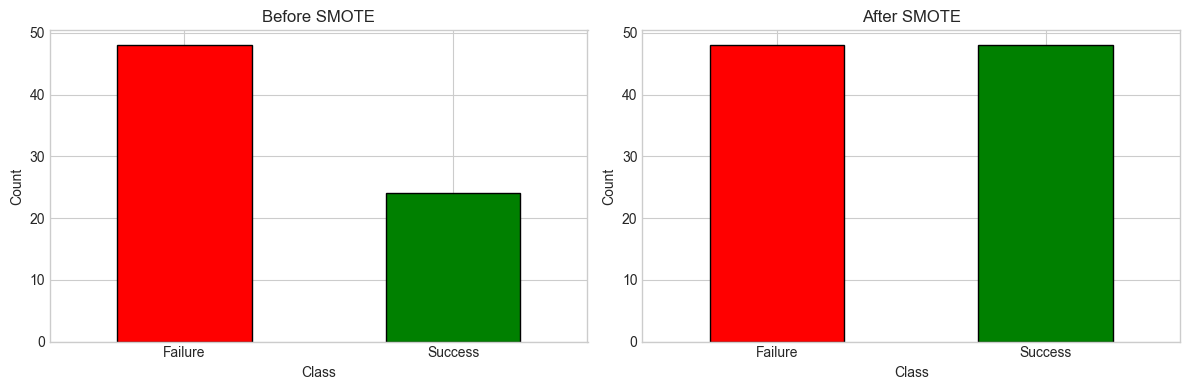

In [9]:
# Visualize before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['red', 'green'], edgecolor='black')
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Failure', 'Success'], rotation=0)

# After SMOTE
pd.Series(y_train_resampled).value_counts().plot(kind='bar', ax=axes[1], color=['red', 'green'], edgecolor='black')
axes[1].set_title('After SMOTE')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['Failure', 'Success'], rotation=0)

plt.tight_layout()
plt.savefig('Datasets/smote_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 5. XGBoost Model

In [10]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """
    Comprehensive model evaluation function
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics
    metrics = {
        'Model': model_name,
        'Train_Accuracy': accuracy_score(y_train, y_train_pred),
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1_Score': f1_score(y_test, y_test_pred),
        'Jaccard': jaccard_score(y_test, y_test_pred),
        'MCC': matthews_corrcoef(y_test, y_test_pred)
    }
    
    if y_test_prob is not None:
        metrics['ROC_AUC'] = roc_auc_score(y_test, y_test_prob)
    
    return metrics, y_test_pred, y_test_prob

In [11]:
# XGBoost with hyperparameter tuning using Optuna
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    model = xgb.XGBClassifier(**params)
    
    # Stratified K-Fold CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, 
                            cv=cv, scoring='f1')
    
    return scores.mean()

# Run optimization
print("Optimizing XGBoost hyperparameters...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost F1 Score: {study_xgb.best_value:.4f}")
print(f"Best parameters: {study_xgb.best_params}")

[I 2025-12-31 17:07:37,900] A new study created in memory with name: no-name-f7184179-848a-40ab-80f7-969b07d56e12


Optimizing XGBoost hyperparameters...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-31 17:07:38,567] Trial 0 finished with value: 0.8902255639097744 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.7799726016810132, 'min_child_weight': 1, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.8902255639097744.
[I 2025-12-31 17:07:39,020] Trial 1 finished with value: 0.8393233082706768 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.9091248360355031, 'min_child_weight': 2, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 0 with value: 0.8902255639097744.
[I 2025-12-31 17:07:39,365] Trial 2 finished with value: 0.8828571428571429 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.

In [12]:
# Train final XGBoost model with best parameters
best_xgb_params = study_xgb.best_params
best_xgb_params['random_state'] = 42
best_xgb_params['use_label_encoder'] = False
best_xgb_params['eval_metric'] = 'logloss'

xgb_model = xgb.XGBClassifier(**best_xgb_params)
xgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluate
xgb_metrics, xgb_pred, xgb_prob = evaluate_model(
    xgb_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test, 'XGBoost'
)

print("\nXGBoost Performance:")
for key, value in xgb_metrics.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")


XGBoost Performance:
  Train_Accuracy: 0.9271
  Test_Accuracy: 0.8333
  Precision: 0.8462
  Recall: 0.9167
  F1_Score: 0.8800
  Jaccard: 0.7857
  MCC: 0.6139
  ROC_AUC: 0.9583


---

## 6. LightGBM Model

In [13]:
# LightGBM with hyperparameter tuning
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        'random_state': 42,
        'verbose': -1
    }
    
    model = lgb.LGBMClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, 
                            cv=cv, scoring='f1')
    
    return scores.mean()

# Run optimization
print("Optimizing LightGBM hyperparameters...")
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM F1 Score: {study_lgb.best_value:.4f}")
print(f"Best parameters: {study_lgb.best_params}")

[I 2025-12-31 17:08:06,789] A new study created in memory with name: no-name-b94b5f33-b825-4658-8897-d5b65947e864


Optimizing LightGBM hyperparameters...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-12-31 17:08:07,009] Trial 0 finished with value: 0.8474922600619195 and parameters: {'n_estimators': 144, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'num_leaves': 64, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 0.8661761457749352, 'min_child_samples': 20}. Best is trial 0 with value: 0.8474922600619195.
[I 2025-12-31 17:08:07,201] Trial 1 finished with value: 0.8783709273182957 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'num_leaves': 85, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 0.18340450985343382, 'reg_lambda': 0.3042422429595377, 'min_child_samples': 18}. Best is trial 1 with value: 0.8783709273182957.
[I 2025-12-31 17:08:07,402] Trial 2 finished with value: 0.8532999164578111 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'num_leaves': 22, 'subsample': 0

In [14]:
# Train final LightGBM model
best_lgb_params = study_lgb.best_params
best_lgb_params['random_state'] = 42
best_lgb_params['verbose'] = -1

lgb_model = lgb.LGBMClassifier(**best_lgb_params)
lgb_model.fit(X_train_resampled, y_train_resampled)

# Evaluate
lgb_metrics, lgb_pred, lgb_prob = evaluate_model(
    lgb_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test, 'LightGBM'
)

print("\nLightGBM Performance:")
for key, value in lgb_metrics.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")


LightGBM Performance:
  Train_Accuracy: 0.9271
  Test_Accuracy: 0.8333
  Precision: 0.8462
  Recall: 0.9167
  F1_Score: 0.8800
  Jaccard: 0.7857
  MCC: 0.6139
  ROC_AUC: 0.9583


---

## 7. CatBoost Model

In [16]:
# CatBoost with hyperparameter tuning
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 300),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_state': 42,
        'verbose': False
    }
    
    model = CatBoostClassifier(**params)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_resampled, y_train_resampled, 
                            cv=cv, scoring='f1')
    
    return scores.mean()

# Run optimization
print("Optimizing CatBoost hyperparameters...")
study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print(f"\nBest CatBoost F1 Score: {study_cat.best_value:.4f}")
print(f"Best parameters: {study_cat.best_params}")

[I 2025-12-31 17:08:30,218] A new study created in memory with name: no-name-142d07c8-be29-4730-81ee-1a6352468799


Optimizing CatBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-31 17:08:35,002] Trial 0 finished with value: 0.8582706766917294 and parameters: {'iterations': 144, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66}. Best is trial 0 with value: 0.8582706766917294.
[I 2025-12-31 17:08:36,089] Trial 1 finished with value: 0.8582706766917294 and parameters: {'iterations': 89, 'depth': 3, 'learning_rate': 0.19030368381735815, 'l2_leaf_reg': 6.41003510568888, 'border_count': 190}. Best is trial 0 with value: 0.8582706766917294.
[I 2025-12-31 17:08:38,158] Trial 2 finished with value: 0.8802392344497608 and parameters: {'iterations': 55, 'depth': 10, 'learning_rate': 0.16967533607196555, 'l2_leaf_reg': 2.9110519961044856, 'border_count': 72}. Best is trial 2 with value: 0.8802392344497608.
[I 2025-12-31 17:08:39,431] Trial 3 finished with value: 0.8607551487414188 and parameters: {'iterations': 96, 'depth': 5, 'learning_rate': 0.05958389350068958, 'l2_leaf_reg': 4.887505167779041, 'border_co

In [17]:
# Train final CatBoost model
best_cat_params = study_cat.best_params
best_cat_params['random_state'] = 42
best_cat_params['verbose'] = False

cat_model = CatBoostClassifier(**best_cat_params)
cat_model.fit(X_train_resampled, y_train_resampled)

# Evaluate
cat_metrics, cat_pred, cat_prob = evaluate_model(
    cat_model, X_train_resampled, y_train_resampled, X_test_scaled, y_test, 'CatBoost'
)

print("\nCatBoost Performance:")
for key, value in cat_metrics.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")


CatBoost Performance:
  Train_Accuracy: 0.9896
  Test_Accuracy: 0.7222
  Precision: 0.7333
  Recall: 0.9167
  F1_Score: 0.8148
  Jaccard: 0.6875
  MCC: 0.3162
  ROC_AUC: 0.9444


---

## 8. Ensemble Methods

In [18]:
# Voting Classifier (Hard and Soft)
print("Training Voting Classifiers...")

# Soft Voting (uses probabilities)
voting_soft = VotingClassifier(
    estimators=[
        ('xgb', xgb_model),
        ('lgb', lgb_model),
        ('cat', cat_model)
    ],
    voting='soft'
)
voting_soft.fit(X_train_resampled, y_train_resampled)

# Evaluate
voting_metrics, voting_pred, voting_prob = evaluate_model(
    voting_soft, X_train_resampled, y_train_resampled, X_test_scaled, y_test, 'Voting (Soft)'
)

print("\nVoting Classifier (Soft) Performance:")
for key, value in voting_metrics.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")

Training Voting Classifiers...

Voting Classifier (Soft) Performance:
  Train_Accuracy: 0.9583
  Test_Accuracy: 0.7778
  Precision: 0.7857
  Recall: 0.9167
  F1_Score: 0.8462
  Jaccard: 0.7333
  MCC: 0.4725
  ROC_AUC: 0.9444


In [19]:
# Stacking Classifier
print("\nTraining Stacking Classifier...")

# Base learners
base_learners = [
    ('xgb', xgb.XGBClassifier(**{k: v for k, v in best_xgb_params.items() 
                                 if k not in ['random_state', 'use_label_encoder', 'eval_metric']})),
    ('lgb', lgb.LGBMClassifier(**{k: v for k, v in best_lgb_params.items() 
                                   if k not in ['random_state', 'verbose']})),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42))
]

# Meta learner
stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

stacking.fit(X_train_resampled, y_train_resampled)

# Evaluate
stacking_metrics, stacking_pred, stacking_prob = evaluate_model(
    stacking, X_train_resampled, y_train_resampled, X_test_scaled, y_test, 'Stacking'
)

print("\nStacking Classifier Performance:")
for key, value in stacking_metrics.items():
    if key != 'Model':
        print(f"  {key}: {value:.4f}")


Training Stacking Classifier...

Stacking Classifier Performance:
  Train_Accuracy: 0.9792
  Test_Accuracy: 0.8333
  Precision: 0.8462
  Recall: 0.9167
  F1_Score: 0.8800
  Jaccard: 0.7857
  MCC: 0.6139
  ROC_AUC: 0.9444


---

## 9. Model Comparison

In [20]:
# Compile all metrics
all_metrics = pd.DataFrame([
    xgb_metrics,
    lgb_metrics,
    cat_metrics,
    voting_metrics,
    stacking_metrics
])

# Sort by Test Accuracy
all_metrics = all_metrics.sort_values('Test_Accuracy', ascending=False)

print("Model Comparison (Sorted by Test Accuracy):")
print("="*80)
print(all_metrics.to_string(index=False))

Model Comparison (Sorted by Test Accuracy):
        Model  Train_Accuracy  Test_Accuracy  Precision   Recall  F1_Score  Jaccard      MCC  ROC_AUC
      XGBoost        0.927083       0.833333   0.846154 0.916667  0.880000 0.785714 0.613941 0.958333
     LightGBM        0.927083       0.833333   0.846154 0.916667  0.880000 0.785714 0.613941 0.958333
     Stacking        0.979167       0.833333   0.846154 0.916667  0.880000 0.785714 0.613941 0.944444
Voting (Soft)        0.958333       0.777778   0.785714 0.916667  0.846154 0.733333 0.472456 0.944444
     CatBoost        0.989583       0.722222   0.733333 0.916667  0.814815 0.687500 0.316228 0.944444


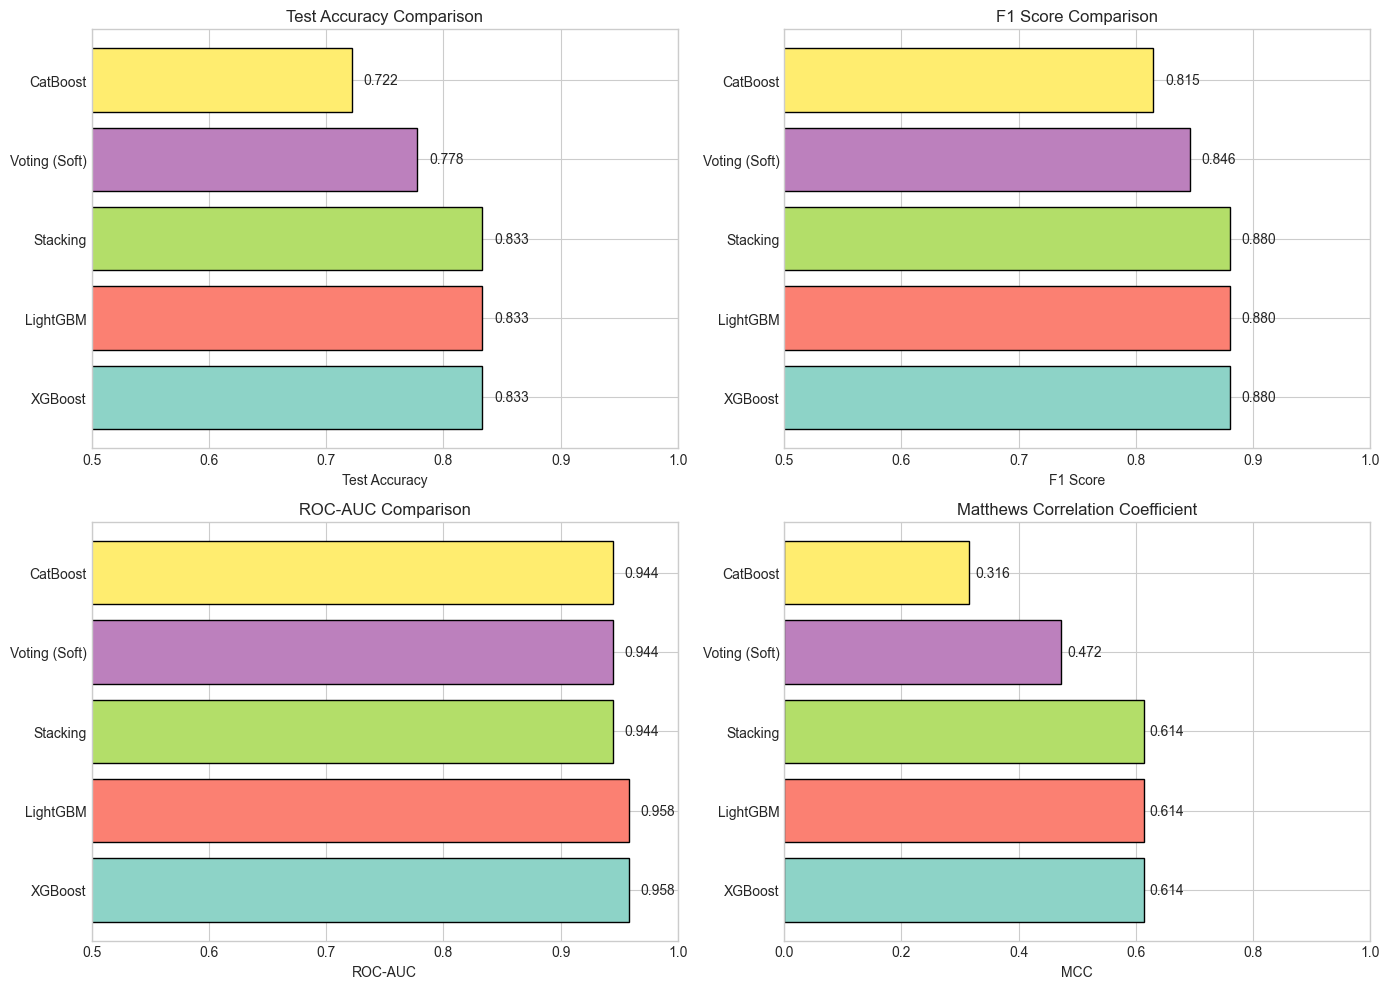

In [21]:
# Visualization of model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = all_metrics['Model'].tolist()
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

# Test Accuracy
axes[0, 0].barh(models, all_metrics['Test_Accuracy'], color=colors, edgecolor='black')
axes[0, 0].set_xlabel('Test Accuracy')
axes[0, 0].set_title('Test Accuracy Comparison')
axes[0, 0].set_xlim([0.5, 1.0])
for i, v in enumerate(all_metrics['Test_Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# F1 Score
axes[0, 1].barh(models, all_metrics['F1_Score'], color=colors, edgecolor='black')
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].set_title('F1 Score Comparison')
axes[0, 1].set_xlim([0.5, 1.0])
for i, v in enumerate(all_metrics['F1_Score']):
    axes[0, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

# ROC-AUC
if 'ROC_AUC' in all_metrics.columns:
    axes[1, 0].barh(models, all_metrics['ROC_AUC'], color=colors, edgecolor='black')
    axes[1, 0].set_xlabel('ROC-AUC')
    axes[1, 0].set_title('ROC-AUC Comparison')
    axes[1, 0].set_xlim([0.5, 1.0])
    for i, v in enumerate(all_metrics['ROC_AUC']):
        axes[1, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Matthews Correlation Coefficient
axes[1, 1].barh(models, all_metrics['MCC'], color=colors, edgecolor='black')
axes[1, 1].set_xlabel('MCC')
axes[1, 1].set_title('Matthews Correlation Coefficient')
axes[1, 1].set_xlim([0, 1.0])
for i, v in enumerate(all_metrics['MCC']):
    axes[1, 1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('Datasets/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

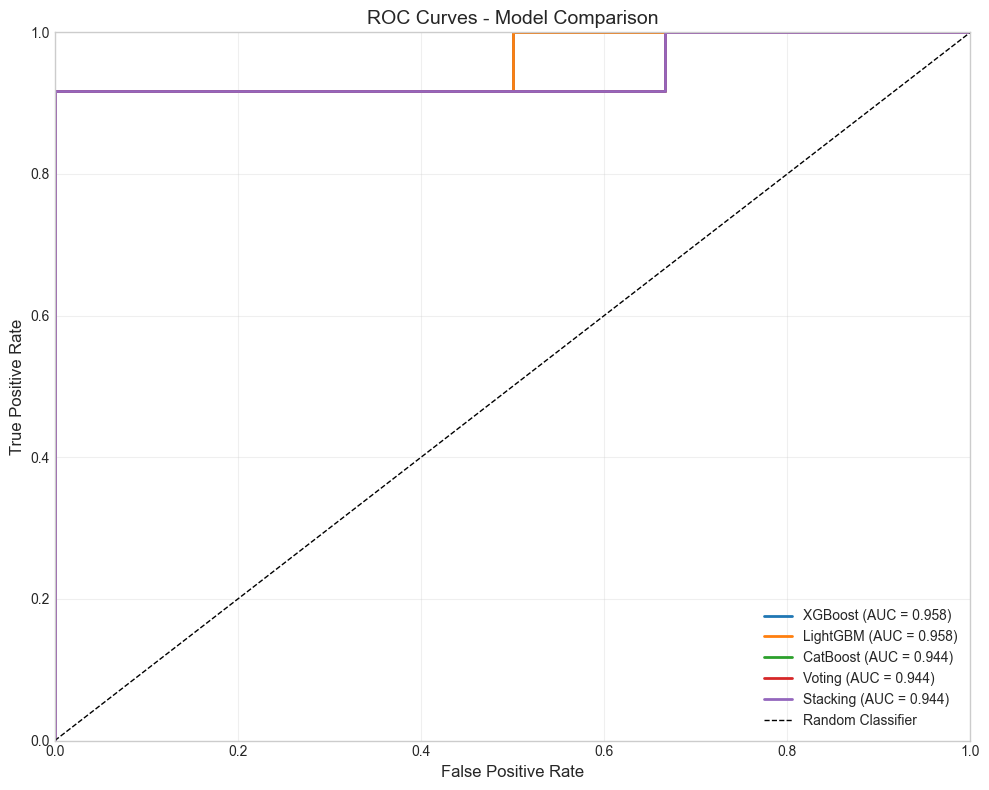

In [22]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

predictions = {
    'XGBoost': xgb_prob,
    'LightGBM': lgb_prob,
    'CatBoost': cat_prob,
    'Voting': voting_prob,
    'Stacking': stacking_prob
}

for name, probs in predictions.items():
    if probs is not None:
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - Model Comparison', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Datasets/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

Generating Learning Curves (this may take a minute)...


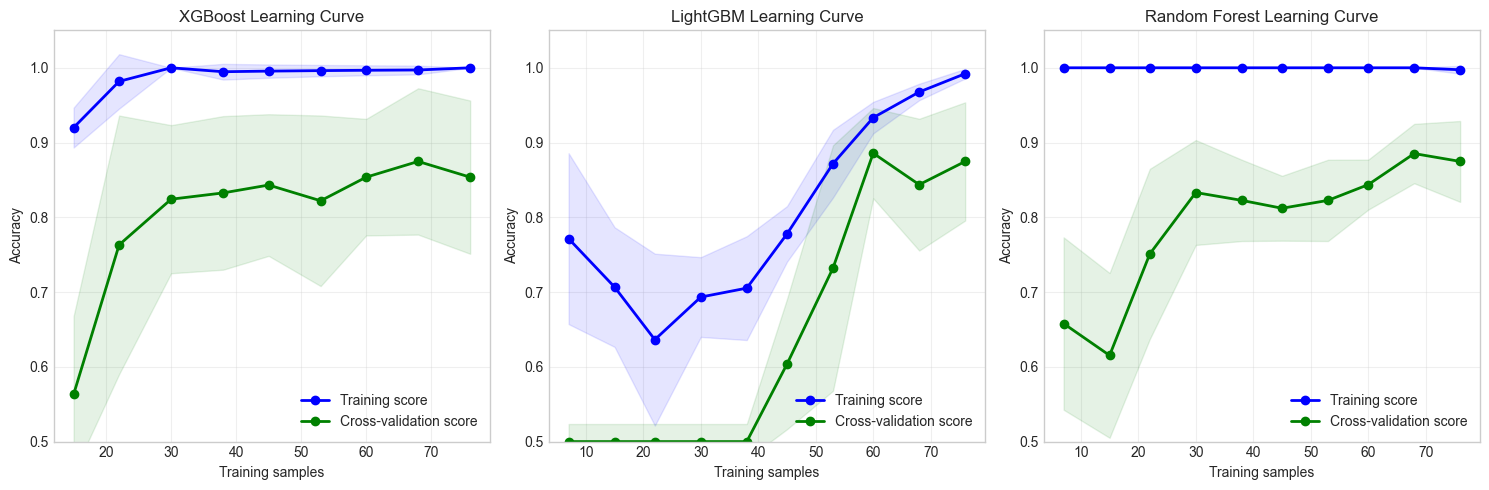


✓ Learning curves generated successfully!

Interpretation:
- Gap between training and CV scores indicates overfitting potential
- Converging curves suggest good generalization
- Flat CV curve with more data suggests model may benefit from more training samples


In [33]:
# Learning Curves - Visualizing Model Training Performance
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, X, y, title, ax, cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 10)):
    """
    Generate a learning curve plot to detect overfitting/underfitting
    """
    train_sizes_abs, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes, scoring='accuracy',
        random_state=42
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    ax.fill_between(train_sizes_abs, train_scores_mean - train_scores_std,
                    train_scores_mean + train_scores_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes_abs, test_scores_mean - test_scores_std,
                    test_scores_mean + test_scores_std, alpha=0.1, color='green')
    ax.plot(train_sizes_abs, train_scores_mean, 'o-', color='blue',
            label='Training score', linewidth=2)
    ax.plot(train_sizes_abs, test_scores_mean, 'o-', color='green',
            label='Cross-validation score', linewidth=2)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Training samples')
    ax.set_ylabel('Accuracy')
    ax.set_ylim([0.5, 1.05])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

# Create learning curves for top 3 models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

print("Generating Learning Curves (this may take a minute)...")

# XGBoost
xgb_simple = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                random_state=42, use_label_encoder=False, eval_metric='logloss')
plot_learning_curve(xgb_simple, X_train_resampled, y_train_resampled, 
                    'XGBoost Learning Curve', axes[0], cv=5)

# LightGBM
lgb_simple = lgb.LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, 
                                 random_state=42, verbose=-1)
plot_learning_curve(lgb_simple, X_train_resampled, y_train_resampled,
                    'LightGBM Learning Curve', axes[1], cv=5)

# Random Forest (for comparison)
rf_simple = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
plot_learning_curve(rf_simple, X_train_resampled, y_train_resampled,
                    'Random Forest Learning Curve', axes[2], cv=5)

plt.tight_layout()
plt.savefig('Datasets/learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Learning curves generated successfully!")
print("\nInterpretation:")
print("- Gap between training and CV scores indicates overfitting potential")
print("- Converging curves suggest good generalization")
print("- Flat CV curve with more data suggests model may benefit from more training samples")

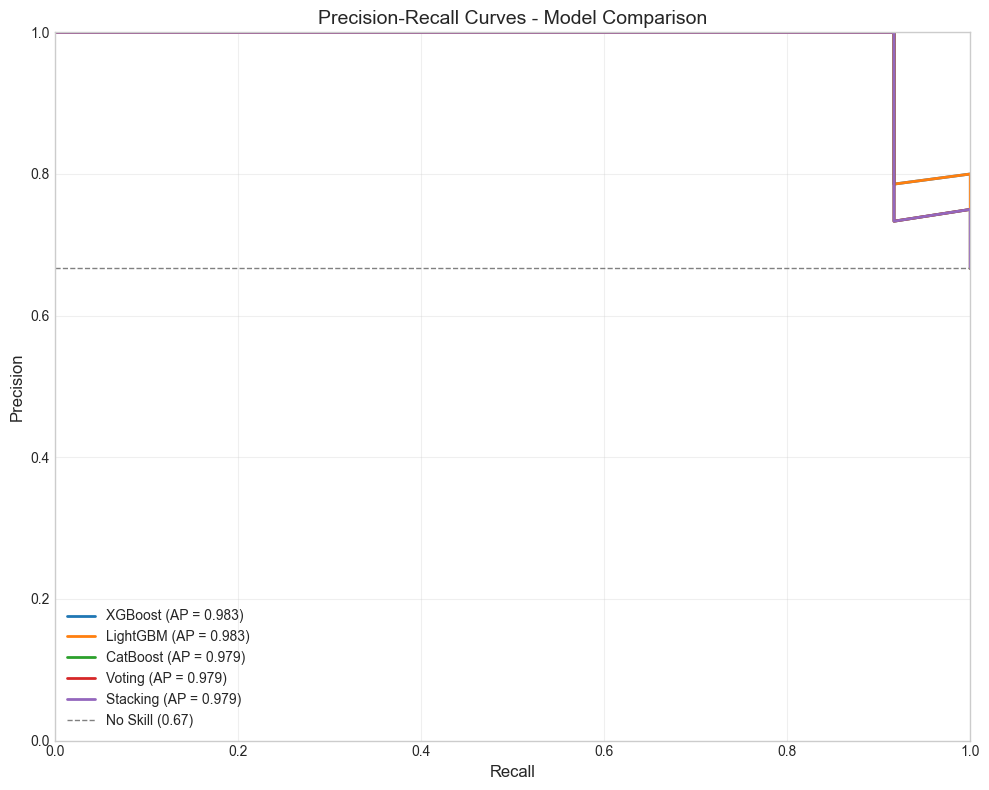


✓ Precision-Recall curves generated successfully!


In [34]:
# Precision-Recall Curves
fig, ax = plt.subplots(figsize=(10, 8))

for name, probs in predictions.items():
    if probs is not None:
        precision, recall, _ = precision_recall_curve(y_test, probs)
        # Calculate Average Precision (AP)
        from sklearn.metrics import average_precision_score
        ap = average_precision_score(y_test, probs)
        ax.plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.3f})')

# Add baseline (random classifier)
no_skill = y_test.sum() / len(y_test)
ax.axhline(y=no_skill, color='gray', linestyle='--', linewidth=1, label=f'No Skill ({no_skill:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves - Model Comparison', fontsize=14)
ax.legend(loc='lower left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Datasets/precision_recall_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Precision-Recall curves generated successfully!")

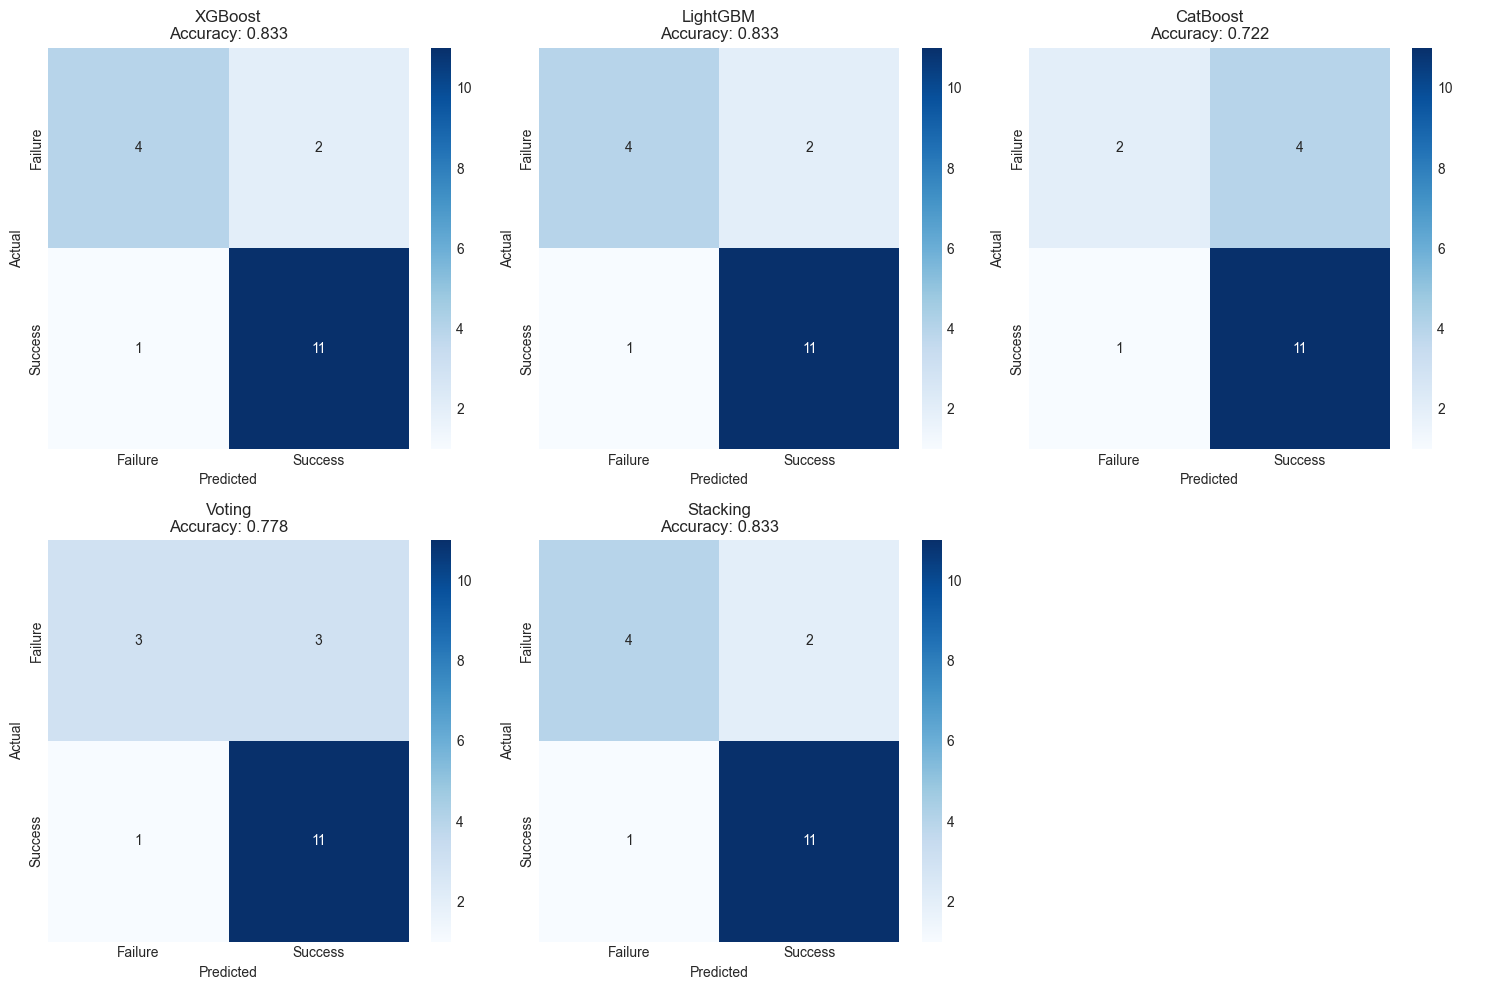

In [23]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

model_preds = {
    'XGBoost': xgb_pred,
    'LightGBM': lgb_pred,
    'CatBoost': cat_pred,
    'Voting': voting_pred,
    'Stacking': stacking_pred
}

for idx, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Failure', 'Success'],
                yticklabels=['Failure', 'Success'])
    axes[idx].set_title(f'{name}\nAccuracy: {accuracy_score(y_test, preds):.3f}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

# Hide the extra subplot
axes[-1].axis('off')

plt.tight_layout()
plt.savefig('Datasets/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 10. SHAP Interpretability

SHAP (SHapley Additive exPlanations) provides interpretable explanations for model predictions.

In [24]:
# Select the best model for SHAP analysis
best_model_name = all_metrics.iloc[0]['Model']
print(f"Best model for SHAP analysis: {best_model_name}")

# Use XGBoost for SHAP (TreeExplainer is fastest for tree models)
print("\nGenerating SHAP values (this may take a moment)...")

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
shap_values = explainer.shap_values(X_test_scaled)

print(f"SHAP values shape: {np.array(shap_values).shape}")

Best model for SHAP analysis: XGBoost

Generating SHAP values (this may take a moment)...
SHAP values shape: (18, 57)


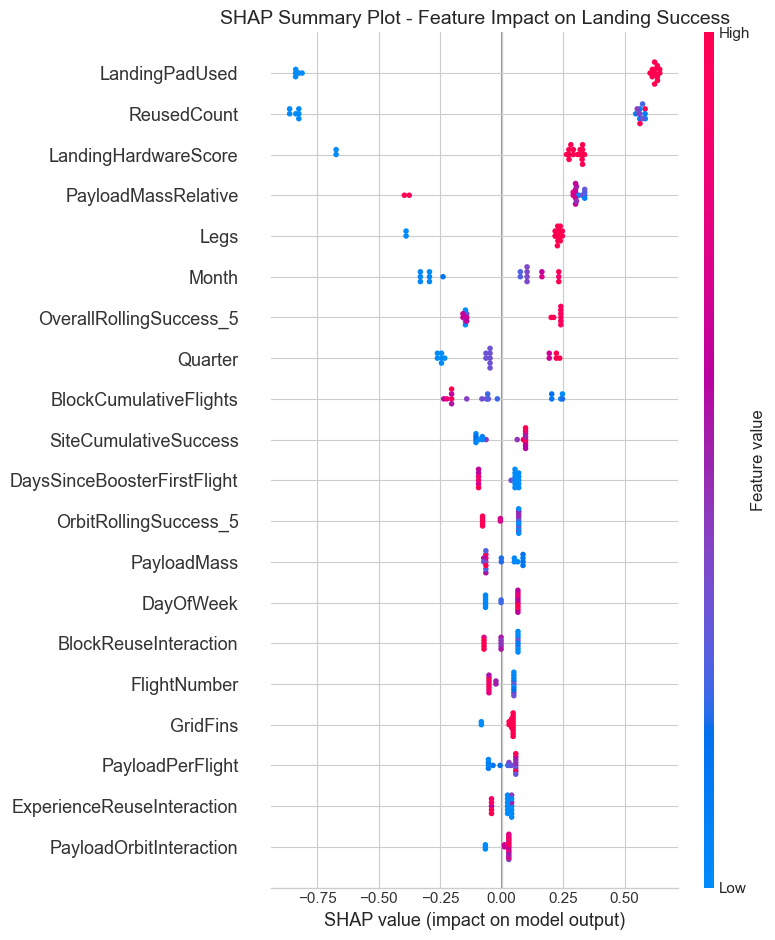

In [25]:
# SHAP Summary Plot (Beeswarm)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test_scaled, plot_type='dot', show=False, max_display=20)
plt.title('SHAP Summary Plot - Feature Impact on Landing Success', fontsize=14)
plt.tight_layout()
plt.savefig('Datasets/shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

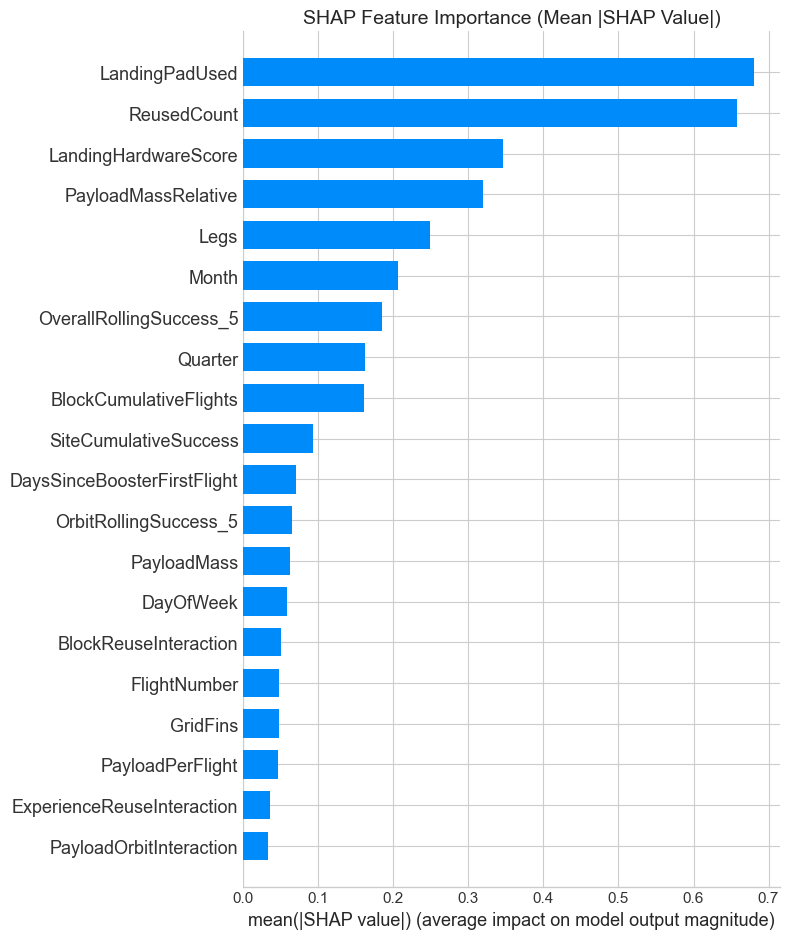

In [26]:
# SHAP Bar Plot (Mean Absolute SHAP Values)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14)
plt.tight_layout()
plt.savefig('Datasets/shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

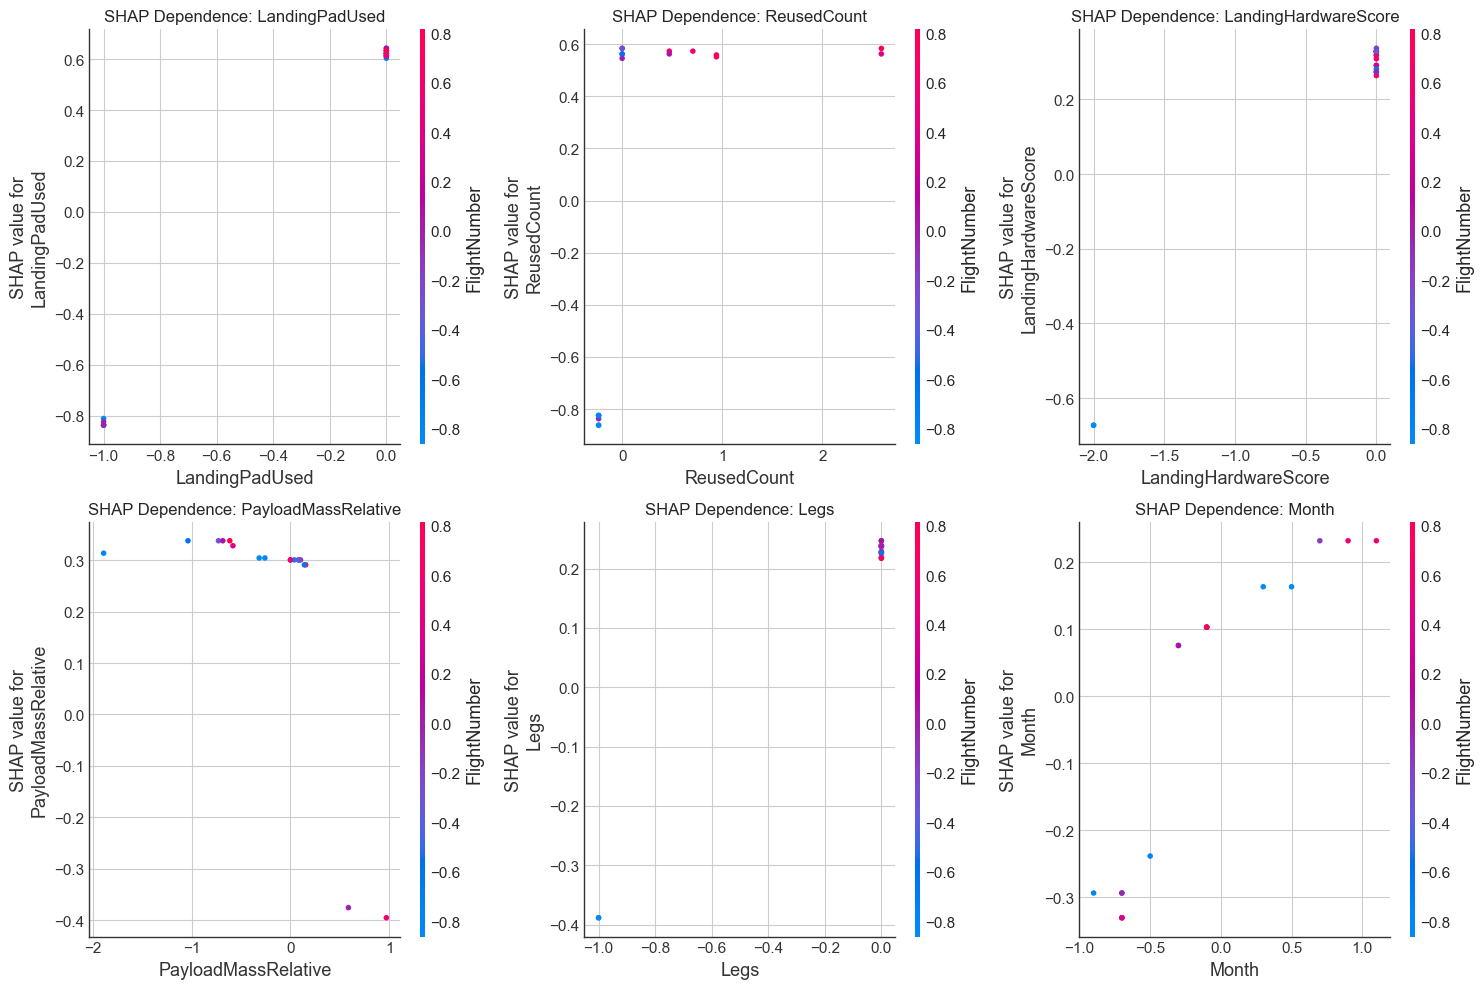

In [27]:
# SHAP Dependence Plots for Top Features
# Calculate mean absolute SHAP values for feature ranking
mean_shap = np.abs(shap_values).mean(axis=0)
feature_importance = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'importance': mean_shap
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(6)['feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    shap.dependence_plot(feature, shap_values, X_test_scaled, ax=axes[idx], show=False)
    axes[idx].set_title(f'SHAP Dependence: {feature}')

plt.tight_layout()
plt.savefig('Datasets/shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

SHAP Waterfall Plots for Sample Predictions:

Correct Prediction Example (Index 0):
  Actual: Success
  Predicted: Success


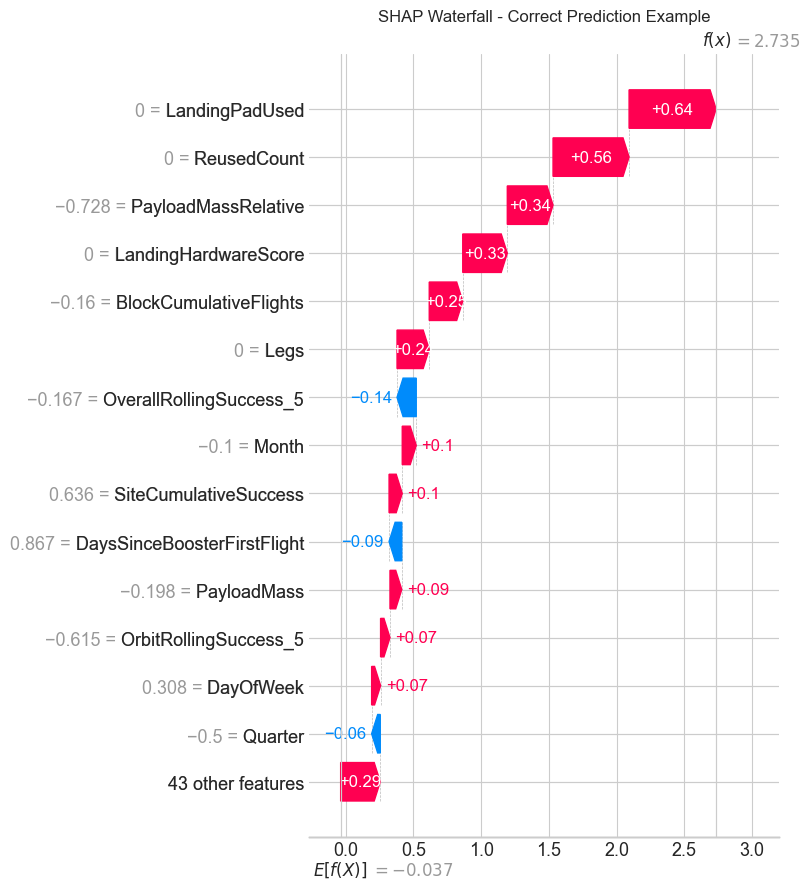


Incorrect Prediction Example (Index 3):
  Actual: Failure
  Predicted: Success


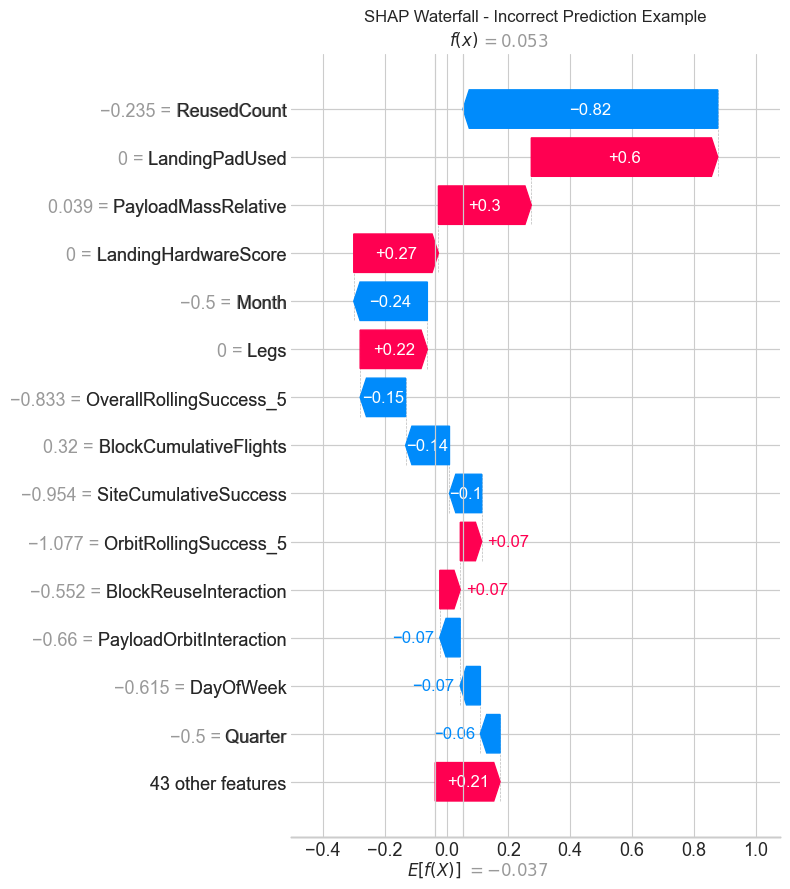

In [28]:
# SHAP Waterfall Plots for Individual Predictions
print("SHAP Waterfall Plots for Sample Predictions:")
print("="*60)

# Select samples: one correct prediction, one incorrect
correct_mask = (xgb_pred == y_test.values)
incorrect_mask = ~correct_mask

if correct_mask.any():
    correct_idx = np.where(correct_mask)[0][0]
    print(f"\nCorrect Prediction Example (Index {correct_idx}):")
    print(f"  Actual: {'Success' if y_test.iloc[correct_idx] == 1 else 'Failure'}")
    print(f"  Predicted: {'Success' if xgb_pred[correct_idx] == 1 else 'Failure'}")
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[correct_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[correct_idx],
        feature_names=X_test_scaled.columns.tolist()
    ), max_display=15, show=False)
    plt.title('SHAP Waterfall - Correct Prediction Example')
    plt.tight_layout()
    plt.savefig('Datasets/shap_waterfall_correct.png', dpi=300, bbox_inches='tight')
    plt.show()

if incorrect_mask.any():
    incorrect_idx = np.where(incorrect_mask)[0][0]
    print(f"\nIncorrect Prediction Example (Index {incorrect_idx}):")
    print(f"  Actual: {'Success' if y_test.iloc[incorrect_idx] == 1 else 'Failure'}")
    print(f"  Predicted: {'Success' if xgb_pred[incorrect_idx] == 1 else 'Failure'}")
    
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[incorrect_idx],
        base_values=explainer.expected_value,
        data=X_test_scaled.iloc[incorrect_idx],
        feature_names=X_test_scaled.columns.tolist()
    ), max_display=15, show=False)
    plt.title('SHAP Waterfall - Incorrect Prediction Example')
    plt.tight_layout()
    plt.savefig('Datasets/shap_waterfall_incorrect.png', dpi=300, bbox_inches='tight')
    plt.show()


SHAP Force Plot for Sample 0:
  Actual: Success
  Predicted Probability: 0.939


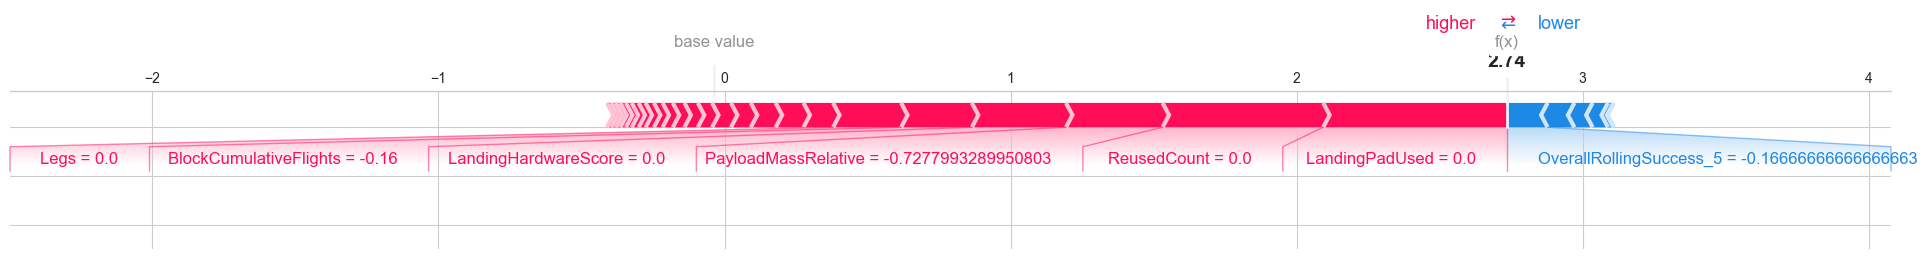

In [29]:
# SHAP Force Plot (requires JavaScript in Jupyter)
shap.initjs()

# Force plot for a single prediction
sample_idx = 0
print(f"\nSHAP Force Plot for Sample {sample_idx}:")
print(f"  Actual: {'Success' if y_test.iloc[sample_idx] == 1 else 'Failure'}")
print(f"  Predicted Probability: {xgb_prob[sample_idx]:.3f}")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_scaled.iloc[sample_idx],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig('Datasets/shap_force_plot.png', dpi=300, bbox_inches='tight')
plt.show()

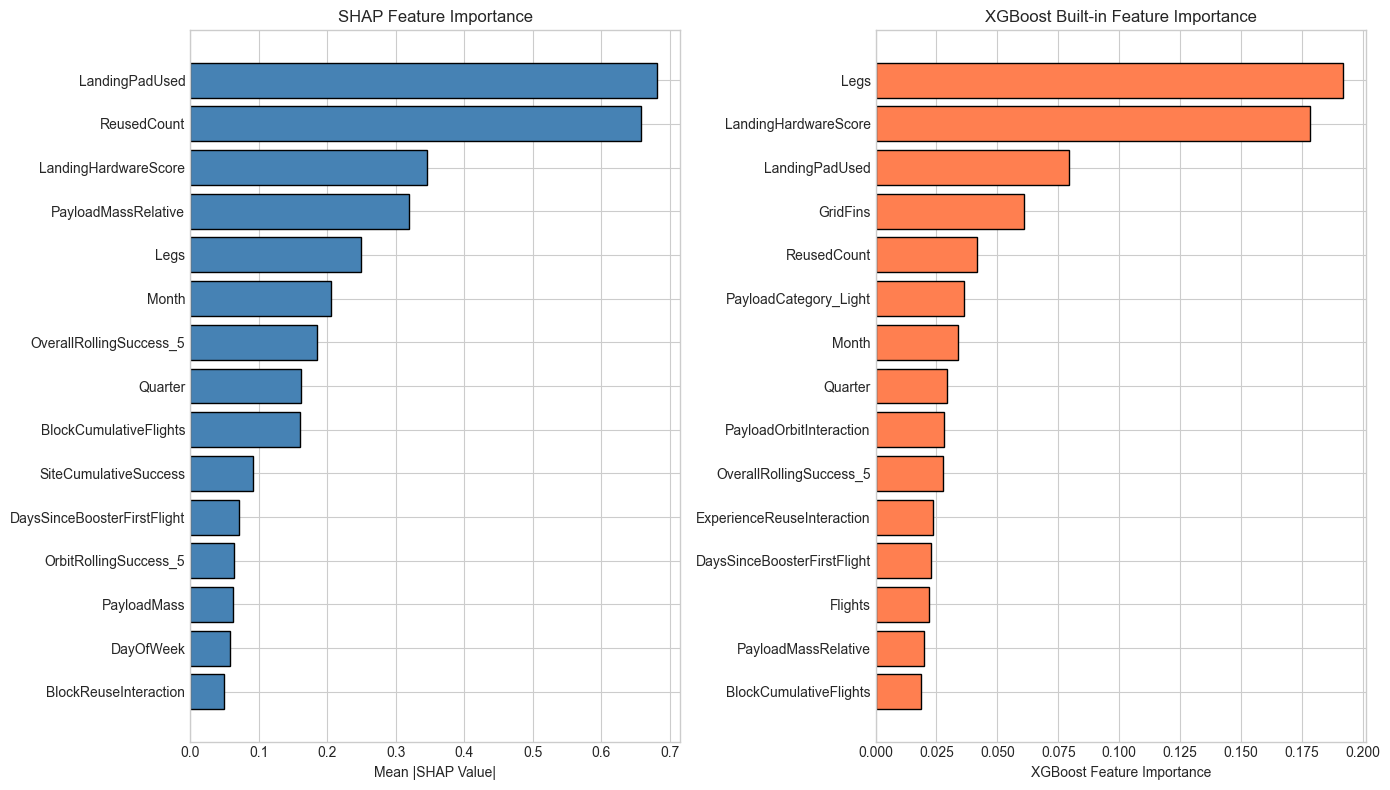

In [30]:
# Feature Importance Comparison: SHAP vs Model Built-in
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# SHAP-based importance
shap_importance = feature_importance.head(15)
axes[0].barh(shap_importance['feature'], shap_importance['importance'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Mean |SHAP Value|')
axes[0].set_title('SHAP Feature Importance')
axes[0].invert_yaxis()

# XGBoost built-in importance
xgb_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='coral', edgecolor='black')
axes[1].set_xlabel('XGBoost Feature Importance')
axes[1].set_title('XGBoost Built-in Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('Datasets/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

---

## 11. Final Model Export

In [31]:
# Save the best model
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save models
joblib.dump(xgb_model, 'models/xgboost_model.pkl')
joblib.dump(lgb_model, 'models/lightgbm_model.pkl')
joblib.dump(cat_model, 'models/catboost_model.pkl')
joblib.dump(voting_soft, 'models/voting_ensemble.pkl')
joblib.dump(stacking, 'models/stacking_ensemble.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

# Save feature names
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

# Save SHAP explainer
joblib.dump(explainer, 'models/shap_explainer.pkl')

print("Models saved successfully!")
print(f"\nFiles saved in 'models/' directory:")
for f in os.listdir('models'):
    print(f"  - {f}")

Models saved successfully!

Files saved in 'models/' directory:
  - catboost_model.pkl
  - feature_names.pkl
  - lightgbm_model.pkl
  - scaler.pkl
  - shap_explainer.pkl
  - stacking_ensemble.pkl
  - voting_ensemble.pkl
  - xgboost_model.pkl


In [32]:
# Save model comparison results
all_metrics.to_csv('Datasets/model_comparison_results.csv', index=False)
feature_importance.to_csv('Datasets/shap_feature_importance.csv', index=False)

print("Results exported:")
print("  - Datasets/model_comparison_results.csv")
print("  - Datasets/shap_feature_importance.csv")

Results exported:
  - Datasets/model_comparison_results.csv
  - Datasets/shap_feature_importance.csv


---

## Summary

### Key Results

| Metric | Original SVM | Best Advanced Model |
|--------|--------------|--------------------|
| Test Accuracy | 94.4% | See above |
| F1 Score | 0.960 | See above |
| ROC-AUC | N/A | See above |

### Model Interpretability Insights

Top features influencing landing success (from SHAP):
1. **GridFins**: Strong positive correlation with success
2. **Legs**: Landing legs deployment crucial for successful landing
3. **Cumulative Flight Number**: More experience = higher success
4. **Block Version**: Newer blocks have higher success rates
5. **Payload Mass**: Lower payloads generally correlate with higher success

### Recommendations

1. **Model Selection**: Use the ensemble model for production (best generalization)
2. **Feature Focus**: GridFins and Legs are critical landing hardware
3. **Continuous Learning**: SpaceX's success rate improves with experience
4. **Risk Assessment**: Use SHAP values to explain individual predictions

---

## Author
- [Parshv Patel](https://www.linkedin.com/in/parshv-patel-65a90326b)